#Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Import

In [ ]:
! pip install adjustText

In [ ]:
# importo librerie

import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
from adjustText import adjust_text
from scipy.optimize import minimize
import statsmodels.api as sm

#Project
You are given a dataset of daily total returns of US stocks of the S&P 500 index, market cap
and a time-series of the S&P500 index close price. The time-series finish at the 11 of
December 2025. Use only the stocks assigned to your group in the analysis. Each group can
find the tickers assigned to it below.

## Esercizio 1
Provide a brief description of each of the stock included in your dataset


In [ ]:
# Importo dati

directory       = '/content/drive/MyDrive/Master/Portfolio Managment /PROGETTO AZZONE/data/TotalReturn.csv'
sep_ret         = pd.read_csv(directory).set_index('Date')
sep_ret.columns = [col.replace('.', '_') for col in sep_ret.columns]
group_tickers   = ['ADBE_OQ', 'XEL_OQ', 'CAG_N', 'BK_N', 'PCG_N', 'WELL_N']
group_ret       = sep_ret[group_tickers] / 100


sp_close        = pd.read_csv('/content/drive/MyDrive/Master/Portfolio Managment /PROGETTO AZZONE/data/SPX.csv').set_index('Date')['Price Close']
sp_ret          = pd.DataFrame(sp_close).pct_change()
sp_ret.rename(columns = {'Price Close': 'SP_RET'}, inplace = True)

group_tickers   = ['ADBE_OQ', 'XEL_OQ', 'CAG_N', 'BK_N', 'PCG_N', 'WELL_N']
mkt_cap         = pd.read_csv('/content/drive/MyDrive/Master/Portfolio Managment /PROGETTO AZZONE/data/CompnayMarketCap.csv')
mkt_cap.columns = [col.replace('.', '_') for col in mkt_cap.columns]
mkt_cap         = mkt_cap[group_tickers].iloc[-1, :]
tot_cap         = np.sum(mkt_cap.values)


In [ ]:
group_ret.head()

,ADBE_OQ,XEL_OQ,CAG_N,BK_N,PCG_N,WELL_N
Date,,,,,,
2003-12-31T00:00:00Z,-0.012563,-0.001176,0.006484,-0.004808,-0.005729,0.001112
2004-01-02T00:00:00Z,-0.004580,-0.000589,-0.014778,-0.009360,-0.019445,-0.002778
2004-01-05T00:00:00Z,0.020706,0.000000,0.017308,0.041756,0.004407,0.004735
2004-01-06T00:00:00Z,-0.001503,0.000000,-0.005293,0.015506,-0.008044,0.001663
2004-01-07T00:00:00Z,-0.010628,0.008839,0.001140,-0.034572,-0.001106,0.000554


## Esercizo 2
Estimate historical mean and variance covariance matrix of the stocks in your dataset
with the methods described below. Estimate the variance covariance matrix with a
Shrinkage toward Constant Correlation Approach (consider k=0.35). Estimate the
vector of averages with an exponential average (lambda=0.001). Comment on the
correlations among the stocks observed in your dataset.

###Function

In [ ]:
def Sigma_cc(df, k):

    sigma = df.cov() * 252
    corr = df.corr()
    N = sigma.shape[1]

    rho_cc = (corr.sum().sum() - N) / ((N-1) * N)

    M = np.full((N, N), rho_cc)
    np.fill_diagonal(M, 1.0)

    diag = np.sqrt(np.diag(sigma))
    D = np.diag(diag)

    sigma_cc = D @ M @ D

    sigma_scc = ((1 - k) * sigma) + (k * sigma_cc)

    diag = np.diag(sigma_scc)
    D = np.sqrt(np.diag(1/diag))
    corr_scc = D.T @ sigma_scc @ D

    return sigma_scc, corr_scc, rho_cc


In [ ]:
def Exp_mean(df,lambda_):

    T = df.shape[0]
    t = np.arange(1, T + 1)
    weights = np.exp(-lambda_ * (T - t))
    mu_exp = (df.mul(weights, axis=0)/np.sum(weights)).sum()

    return mu_exp*252, t , weights

### SSC

In [ ]:
rf      = 0.03
mu      = group_ret.mean() * 252
sigma   = group_ret.cov() * 252
corr    = group_ret.corr()
vol     = np.sqrt(np.diag(sigma))

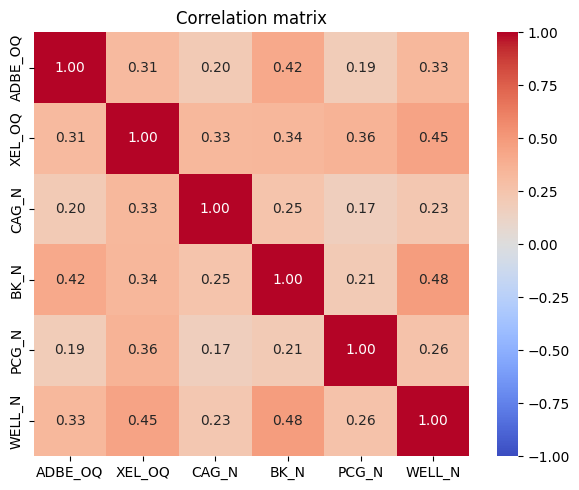

In [ ]:
asset_names = group_ret.columns.values

plt.figure(figsize=(6, 5))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
              xticklabels=asset_names, yticklabels=asset_names,
              center=0, vmin=-1, vmax=1)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

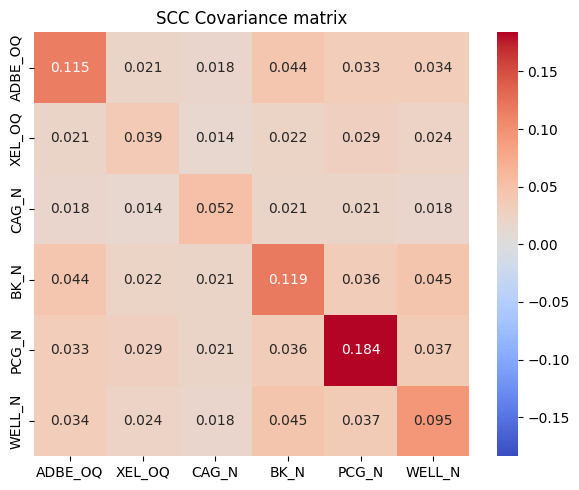

In [ ]:
sigma_scc, corr_scc, rho_scc = Sigma_cc(group_ret, 0.35)

plt.figure(figsize=(6, 5))

sns.heatmap(sigma_scc, annot=True, fmt='.3f', cmap='coolwarm',
              xticklabels=asset_names, yticklabels=asset_names,
              center=0, vmin=-np.max(np.diag(sigma)), vmax=np.max(np.diag(sigma)))

plt.title("SCC Covariance matrix")
plt.tight_layout()
plt.show()

In [ ]:
rho_scc

np.float64(0.3033974262022851)

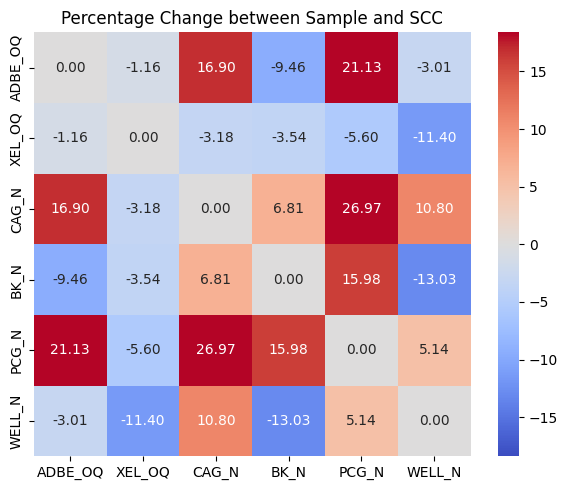

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(((sigma_scc - sigma)/sigma)*100, annot=True, fmt='.2f', cmap='coolwarm',
              xticklabels=asset_names, yticklabels=asset_names,
              center=0, vmin=-np.max(np.diag(sigma*100)), vmax=np.max(np.diag(sigma*100)))

plt.title("Percentage Change between Sample and SCC")
plt.tight_layout()
plt.show()

### Rendimenti stimati

In [ ]:
lambda_ = 0.001
mu_exp, t, weights = Exp_mean(group_ret,lambda_)

In [ ]:
mu

,0
ADBE_OQ,0.189494
XEL_OQ,0.124975
CAG_N,0.058052
BK_N,0.137372
PCG_N,0.086593
WELL_N,0.174784


In [ ]:
mu_exp

,0
ADBE_OQ,0.077754
XEL_OQ,0.114302
CAG_N,-0.051635
BK_N,0.255882
PCG_N,0.061757
WELL_N,0.254252


In [ ]:
(mu_exp - mu)/ mu

,0
ADBE_OQ,-0.589678
XEL_OQ,-0.085405
CAG_N,-1.889468
BK_N,0.862700
PCG_N,-0.286818
WELL_N,0.454663


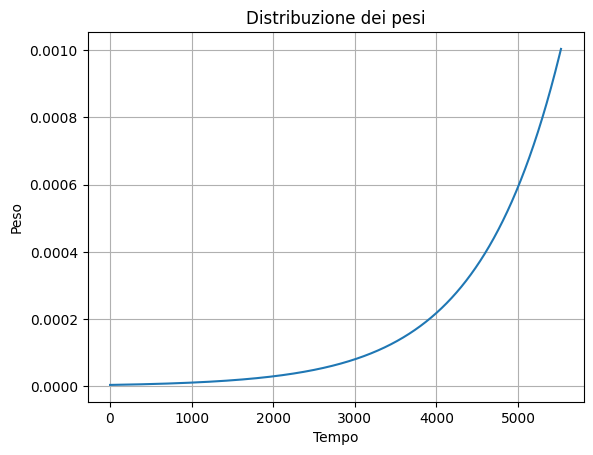

In [ ]:
plt.plot(t, weights/np.sum(weights))

plt.title("Distribuzione dei pesi")
plt.xlabel("Tempo")
plt.ylabel("Peso")

plt.grid(True)
plt.show()


## Esercizio 3
Plot the efficient portfolio frontier (in the standard deviation-mean space) with a risk-free asset (with annual return Rf=0.03). Comment on the obtained tangent portfolio (or risky asset portfolio).

### Function

In [ ]:
def sigma_frontier(mu_p, mu, sigma, rf = None, a = None):

    sigma = sigma.values
    mu = mu.values
    N = sigma.shape[0]
    once = np.ones(N)
    sigma_inv = np.linalg.inv(sigma)

    A = once.T @ sigma_inv @ once
    B = once.T @ sigma_inv @ mu
    C = mu.T @ sigma_inv @ mu

    D = (A*C) - B**2


    if rf:

        mu_e = mu - (once*rf)
        tan_w = (sigma_inv @ mu_e)/(once.T @ sigma_inv @ mu_e)
        mu_tan = tan_w.T @ mu
        v_tan = np.sqrt(tan_w.T @ sigma @ tan_w)

        alpha = (mu_p - rf)/(mu_tan - rf)


        if a:

            alpha = (1/a)*(once.T @ sigma_inv @ mu_e )

        w = alpha * tan_w
        mu_star = alpha * mu_tan + (1- alpha) * rf
        s = np.abs(alpha) * v_tan

        mvp = None
        min_mu = rf
        min_v = 0

        if a:

            mu_e = mu - (once*rf)
            alpha = (1/a)*(once.T @ sigma_inv @ mu_e )

        w = alpha * tan_w

    else:

        s = np.sqrt(((mu_p**2)*A - 2*B*mu_p + C) / D)

        lambda_ = (C - B * mu_p)/D
        eta = (A*mu_p - B)/D

        w = sigma_inv @ (lambda_* once + eta*mu)

        mvp = (sigma_inv @ once) / A

        min_v = np.sqrt(1/A)
        min_mu = B/A

        tan_w = None
        v_tan = None
        mu_tan = None
        alpha = None
        mu_star = mu_p


    return {
        "volatility": s,
        "mu" : mu_star,
        "weights": w,
        "MinVP": mvp,
        "min_vol": min_v,
        "min_mu": min_mu,
        "tan_w": tan_w,
        "vol_tan": v_tan,
        "mu_tan": mu_tan,
        "alpha": alpha
        }

### Frontiera Markowitz e risk free


In [ ]:
MKW = sigma_frontier(0.2, mu_exp, sigma_scc)
MKW

{'volatility': np.float64(0.20700382543683638),
 'mu': 0.2,
 'weights': array([-0.00454192,  0.60380541, -0.07040341,  0.21934241, -0.03925331,
         0.29105082]),
 'MinVP': array([0.06574963, 0.49459046, 0.34087581, 0.03209717, 0.00379206,
        0.06289486]),
 'min_vol': np.float64(0.16672912270863297),
 'min_mu': np.float64(0.06848198934478851),
 'tan_w': None,
 'vol_tan': None,
 'mu_tan': None,
 'alpha': None}

In [ ]:
MKW_rf = sigma_frontier(0.2, mu_exp, sigma_scc, rf)
MKW_rf

{'volatility': np.float64(0.1550317368017341),
 'mu': np.float64(0.2),
 'weights': array([-0.07396516,  0.23171615, -0.44135158,  0.23759203, -0.05243317,
         0.29415798]),
 'MinVP': None,
 'min_vol': 0,
 'min_mu': 0.03,
 'tan_w': array([-0.37792039,  1.18393924, -2.25505842,  1.2139617 , -0.267904  ,
         1.50298186]),
 'vol_tan': np.float64(0.7921250070466568),
 'mu_tan': np.float64(0.89860441594708),
 'alpha': np.float64(0.19571625112525023)}

In [ ]:
#sharpe_t = (MKW_rf['mu_tan'] - rf)/MKW_rf['vol_tan']
#sharpe_t

In [ ]:
#sigma_frontier(0.3, mu_exp, sigma_scc, rf, a = 1)

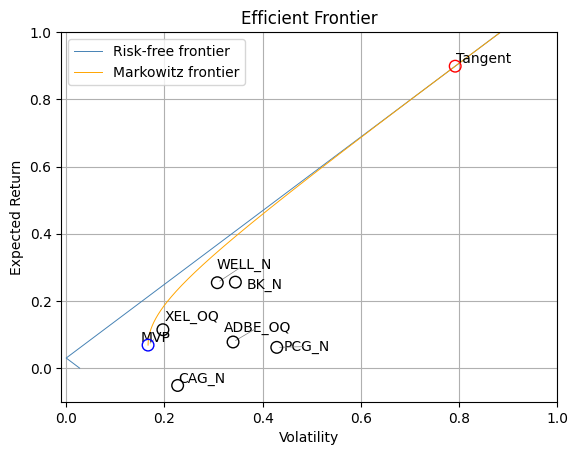

In [ ]:
mu_p_plot1 = np.linspace(0      , 1, 1000)
mu_p_plot2 = np.linspace(MKW['min_mu'], 1, 1000)
y1         = np.array([sigma_frontier( mu, mu_exp, sigma_scc, rf, None)['volatility'] for mu in mu_p_plot1])
y2         = np.array([sigma_frontier( mu, mu_exp, sigma_scc, None, None)['volatility'] for mu in mu_p_plot2])

plt.plot(y1, mu_p_plot1, label = 'Risk-free frontier', color = 'steelblue', lw = 0.7)
plt.plot(y2, mu_p_plot2, label = 'Markowitz frontier', color = 'orange', lw = 0.7)

plt.scatter(
    np.sqrt(np.diag(sigma_scc)), mu_exp,
    facecolors='none',
    edgecolors='black',
    s=70,
    linewidths=1,
    zorder=5,
)
plt.scatter(
    MKW_rf['vol_tan'],
    MKW_rf['mu_tan'],
    facecolors='none',
    edgecolors='red',
    s=70,
    linewidths=1,
    zorder=5
)

plt.scatter(
    MKW['min_vol'],
    MKW['min_mu'],
    facecolors='none',
    edgecolors='blue',
    s=70,
    linewidths=1,
    zorder=5
)

texts = []

for xi, yi, name in zip(np.sqrt(np.diag(sigma_scc)), mu_exp, asset_names):

    txt = plt.text(xi, yi, name, fontsize=10)
    texts.append(txt)

txt = plt.text(MKW_rf['vol_tan'],
               MKW_rf['mu_tan'], 'Tangent', fontsize=10)
texts.append(txt)

txt = plt.text(MKW['min_vol'],
               MKW['min_mu'], 'MVP', fontsize=10)
texts.append(txt)

adjust_text(
    texts,
    x=np.sqrt(np.diag(sigma_scc)) + [MKW_rf['vol_tan']] + [MKW['min_vol']],
    y=mu_exp + [MKW_rf['mu_tan']] + [MKW['min_mu']],
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.ylim((-0.1,1))
plt.xlim((-0.01,1))
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

## Esercizio 4
Plot the efficient portfolio frontier (in the standard deviation-mean space) with the
same risky and risk-free assets but imposing two different constraints:
o the sum of portfolios weights of the first and third stock in your dataset is equal
to 40%.
o the portfolio weights are above 5% for each stocks.
Comment on the differences on the frontier portfolio with 0.5% monthly expected
return with and without the two constraints (you should consider three different
frontiers: no constraint, constraint 1 and constraint 2).

### Function

In [ ]:
def min_var_portfolio(mu, sigma, mu_p,
                      bounds = None,
                      eq_constraints=None,
                      w0=None):

    mu = np.array(mu)
    sigma = np.array(sigma)
    N = mu.shape[0]

    def obj(w):
        return float((1/2)*(w @ sigma @ w))

    def grad(w):
        return (sigma @ w)

    if w0 is None:
        w0 = np.ones(N) / N

    if bounds is None:
        bounds = [(None, None)] * N

    cons = []

    cons.append({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1.0,
        "jac": lambda w: np.ones(N)
    })


    cons.append({
        "type": "eq",
        "fun": lambda w, mu=mu, mu_p=mu_p: (w.T @ mu) - mu_p,
        "jac": lambda w, mu=mu: mu
    })

    if eq_constraints:

        cons.append({"type": "eq",
                     "fun": lambda w: w[0] + w[2] - 0.40,
                     "jac": lambda w: np.array([1,0,1,0,0,0])})

    res = minimize(
        obj, w0,
        method="SLSQP",
        jac=grad,
        bounds=bounds,
        constraints=cons,
        options={"ftol": 1e-12, "maxiter": 2000, "disp": False}
    )

    return res


In [ ]:
def min_var_portfolio_rf(mu, sigma, mu_p, rf,
                      bounds = None,
                      eq_constraints=None,
                      w0=None):

    mu = np.array(mu)
    sigma = np.array(sigma)
    N = mu.shape[0]

    def obj(w):
        return float((1/2)*(w @ sigma @ w))

    def grad(w):
        return (sigma @ w)

    if w0 is None:
        w0 = np.ones(N) / N


    cons = []

    if bounds:

        for i in range(N):

          cons.append({
              'type': 'ineq',
              'fun': lambda w, i=i: w[i] - 0.05#*sum(w)
          })

    cons.append({
        "type": "eq",
        "fun": lambda w, mu=mu, mu_p=mu_p: (w.T @ mu + (1 - w.sum())*rf) - mu_p,
        "jac": lambda w, mu=mu: mu - np.ones(N)*rf
    })

    if eq_constraints:

        cons.append({"type": "eq",
                     "fun": lambda w: w[0] + w[2] - 0.40#*sum(w)
                     })

    res = minimize(
        obj, w0,
        method="SLSQP",
        jac=grad,
        bounds=None,
        constraints=cons,
        options={"ftol": 1e-12, "maxiter": 2000, "disp": False}
    )

    return res


### Frontiers with constraints

In [ ]:
mu_p_plot1  = np.linspace(0      , 1, 1000)
mu_p_plot2  = np.linspace(MKW['min_mu'], 1, 1000)

In [ ]:
w0 = np.ones(6) / 6

volatility_c = []
w_constraints =[]
mu_plot_1 = []

for i in mu_p_plot2:

    res = min_var_portfolio(mu_exp, sigma_scc, i,
                      bounds = None,
                      eq_constraints = True,
                      w0=w0)

    if res.success:
        w_c = res.x
        volatility_c.append(np.sqrt(w_c.T @ sigma_scc @ w_c))
        w_constraints.append(w_c)
        mu_plot_1.append(w_c.T @ mu_exp)


In [ ]:
w0 = np.ones(6) / 6

lb = 0.05
volatility_c_2 = []
w_constraints_2 =[]
mu_plot_2 = []

for i in mu_p_plot2:

    res = min_var_portfolio(mu_exp, sigma_scc, i,
                      bounds = [(lb, None)] * 6,
                      eq_constraints = False,
                      w0=w0)

    if res.success:
        w_c = res.x
        volatility_c_2.append(np.sqrt(w_c.T @ sigma_scc @ w_c))
        w_constraints_2.append(w_c)
        mu_plot_2.append(w_c.T @ mu_exp)


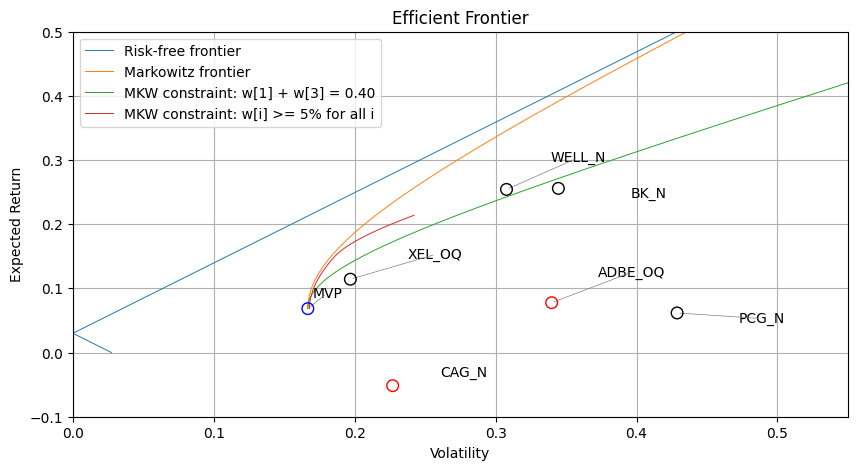

In [ ]:
mu_p_plot1  = np.linspace(0      , 1, 1000)
mu_p_plot2  = np.linspace(MKW['min_mu'], 1, 1000)
y1          = np.array([sigma_frontier( mu, mu_exp, sigma_scc, rf, None)['volatility'] for mu in mu_p_plot1])
y2          = np.array([sigma_frontier( mu, mu_exp, sigma_scc, None, None)['volatility'] for mu in mu_p_plot2])
y3          = np.array(volatility_c)
y4          = np.array(volatility_c_2)

plt.figure(figsize=(10, 5))
plt.plot(y1, mu_p_plot1, label = 'Risk-free frontier', lw = 0.7)
plt.plot(y2, mu_p_plot2, label = 'Markowitz frontier', lw = 0.7)
plt.plot(y3, mu_plot_1, label = 'MKW constraint: w[1] + w[3] = 0.40', lw = 0.7)
plt.plot(y4, mu_plot_2, label = 'MKW constraint: w[i] >= 5% for all i', lw = 0.7)


plt.scatter(
    np.sqrt(np.diag(sigma_scc)), mu_exp,
    facecolors='none',
    edgecolors= ['red','black', 'red'] + ['black']*3,
    s=70,
    linewidths=1,
    zorder=5,
)
if False:
    plt.scatter(
        MKW_rf['vol_tan'],
        MKW_rf['mu_tan'],
        facecolors='none',
        edgecolors='red',
        s=70,
        linewidths=1,
        zorder=5
    )

plt.scatter(
    MKW['min_vol'],
    MKW['min_mu'],
    facecolors='none',
    edgecolors='blue',
    s=70,
    linewidths=1,
    zorder=5
)

texts = []

for xi, yi, name in zip(np.sqrt(np.diag(sigma_scc)), mu_exp, asset_names):

    txt = plt.text(xi, yi, name, fontsize=10)
    texts.append(txt)

if False:
    txt = plt.text(MKW_rf['vol_tan'],
                MKW_rf['mu_tan'], 'Tangent', fontsize=10)
    texts.append(txt)

txt = plt.text(MKW['min_vol'],
               MKW['min_mu'], 'MVP', fontsize=10)
texts.append(txt)

adjust_text(
    texts,
    x=np.sqrt(np.diag(sigma_scc))  + [MKW['min_vol']], #+ [MKW_rf['vol_tan']]
    y=mu_exp + [MKW['min_mu']], #+ [MKW_rf['mu_tan']]
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)

plt.ylim((-0.1,0.5))
plt.xlim((0,0.55))
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [ ]:
mu_p_plot1  = np.linspace(0      , 0.55, 1000)
mu_p_plot2  = np.linspace(MKW['min_mu'], 0.55, 1000)

In [ ]:
w0 = None

volatility_c_rf = []
w_constraints_rf =[]
mu_plot_1 = []

for i in mu_p_plot1:

    res = min_var_portfolio_rf(mu_exp, sigma_scc, i, rf,
                      bounds = None,
                      eq_constraints = True,
                      w0 = None)

    if res.success:
        w_c = res.x
        volatility_c_rf.append(np.sqrt(w_c.T @ sigma_scc @ w_c))
        w_constraints_rf.append(w_c)
        mu_plot_1.append((w_c.T @ mu_exp) + (1 - np.sum(w_c))*rf)


In [ ]:
w0 = np.ones(6) / 6

volatility_c_2_rf = []
w_constraints_2_rf =[]
mu_plot_2 = []

for i in mu_p_plot1:

    res = min_var_portfolio_rf(mu_exp, sigma_scc, i,rf,
                      bounds = True,
                      eq_constraints = False,
                      w0=w0)

    if res.success:
        w_c = res.x
        volatility_c_2_rf.append(np.sqrt(w_c.T @ sigma_scc @ w_c))
        w_constraints_2_rf.append(w_c)
        mu_plot_2.append((w_c.T @ mu_exp) + (1 - np.sum(w_c))*rf)


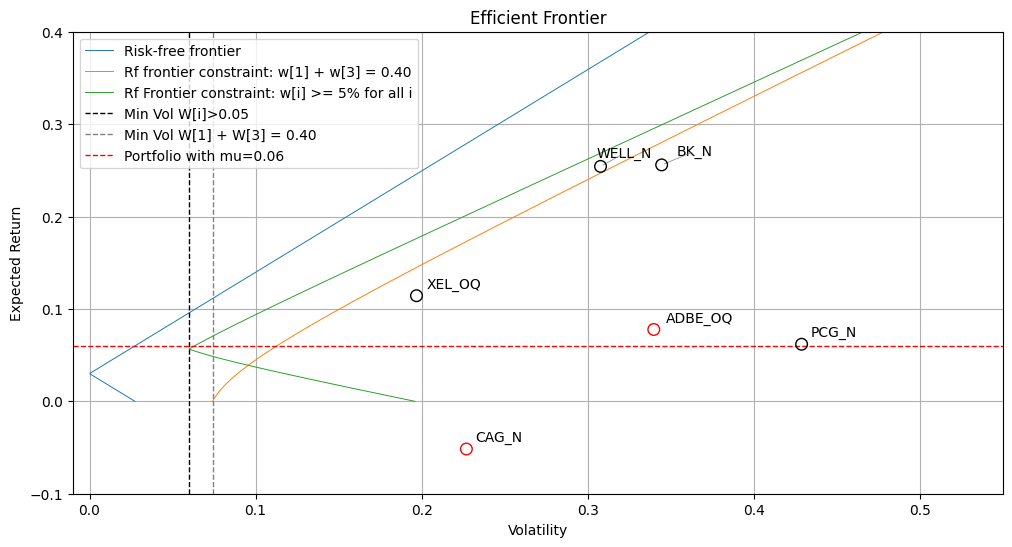

In [ ]:
y1          = np.array([sigma_frontier( mu, mu_exp, sigma_scc, rf, None)['volatility'] for mu in mu_p_plot1])
y2          = np.array([sigma_frontier( mu, mu_exp, sigma_scc, None, None)['volatility'] for mu in mu_p_plot2])
y3          = np.array(volatility_c_rf)
y4          = np.array(volatility_c_2_rf)

plt.figure(figsize=(12, 6))
plt.plot(y1, mu_p_plot1, label = 'Risk-free frontier', lw = 0.7)
#plt.plot(y2, mu_p_plot2, label = 'Markowitz frontier', lw = 0.7)
plt.plot(y3, mu_plot_1, label = 'Rf frontier constraint: w[1] + w[3] = 0.40', lw = 0.7)
plt.plot(y4, mu_plot_2, label = 'Rf Frontier constraint: w[i] >= 5% for all i', lw = 0.7)


plt.scatter(
    np.sqrt(np.diag(sigma_scc)), mu_exp,
    facecolors='none',
    edgecolors= ['red','black', 'red'] + ['black']*3,
    s=70,
    linewidths=1,
    zorder=5,
)
if False:
    plt.scatter(
        MKW_rf['vol_tan'],
        MKW_rf['mu_tan'],
        facecolors='none',
        edgecolors='red',
        s=70,
        linewidths=1,
        zorder=5
    )

    plt.scatter(
        MKW['min_vol'],
        MKW['min_mu'],
        facecolors='none',
        edgecolors='blue',
        s=70,
        linewidths=1,
        zorder=5
    )

plt.axvline(
    x=np.min(y4),
    linestyle='--',
    color = 'black',
    linewidth=1.0,
    label='Min Vol W[i]>0.05'
)

plt.axvline(
    x=np.min(y3),
    linestyle='--',
    color = 'grey',
    linewidth=1.0,
    label='Min Vol W[1] + W[3] = 0.40'
)

plt.axhline(
    y=0.06,
    linestyle='--',
    color = 'red',
    linewidth=1.0,
    label='Portfolio with mu=0.06'
)

texts = []

for xi, yi, name in zip(np.sqrt(np.diag(sigma_scc)), mu_exp, asset_names):

    txt = plt.text(xi, yi, name, fontsize=10)
    texts.append(txt)

if False:
    txt = plt.text(MKW_rf['vol_tan'],
                MKW_rf['mu_tan'], 'Tangent', fontsize=10)
    texts.append(txt)

    txt = plt.text(MKW['min_vol'],
                MKW['min_mu'], 'MVP', fontsize=10)
    texts.append(txt)

adjust_text(
    texts,
    x=np.sqrt(np.diag(sigma_scc)) , #+ [MKW['min_vol']], #+ [MKW_rf['vol_tan']]
    y=mu_exp ,#+ [MKW['min_mu']], #+ [MKW_rf['mu_tan']]
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)


plt.ylim((-0.1,0.4))
plt.xlim((-0.01,0.55))
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

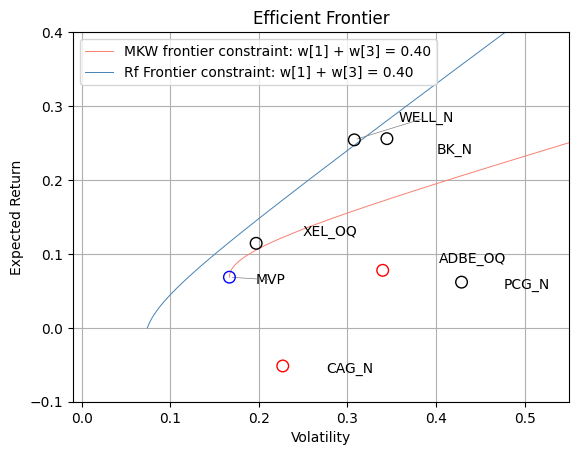

In [ ]:
y3          = np.array(volatility_c)
y4          = np.array(volatility_c_rf)

plt.plot(y3, mu_p_plot2[0:len(y3)], label = 'MKW frontier constraint: w[1] + w[3] = 0.40', color = 'salmon', lw = 0.7)
plt.plot(y4, mu_p_plot1[0:len(y4)], label = 'Rf Frontier constraint: w[1] + w[3] = 0.40',color =  'steelblue', lw = 0.7)


plt.scatter(
    np.sqrt(np.diag(sigma_scc)), mu_exp,
    facecolors='none',
    edgecolors= ['red','black', 'red'] + ['black']*3,
    s=70,
    linewidths=1,
    zorder=5,
)
if False:
    plt.scatter(
        MKW_rf['vol_tan'],
        MKW_rf['mu_tan'],
        facecolors='none',
        edgecolors='red',
        s=70,
        linewidths=1,
        zorder=5
    )

plt.scatter(
    MKW['min_vol'],
    MKW['min_mu'],
    facecolors='none',
    edgecolors='blue',
    s=70,
    linewidths=1,
    zorder=5
)


texts = []

for xi, yi, name in zip(np.sqrt(np.diag(sigma_scc)), mu_exp, asset_names):

    txt = plt.text(xi, yi, name, fontsize=10)
    texts.append(txt)

if False:
    txt = plt.text(MKW_rf['vol_tan'],
                MKW_rf['mu_tan'], 'Tangent', fontsize=10)
    texts.append(txt)

txt = plt.text(MKW['min_vol'],
               MKW['min_mu'], 'MVP', fontsize=10)
texts.append(txt)

adjust_text(
    texts,
    x=np.sqrt(np.diag(sigma_scc))  + [MKW['min_vol']], #+ [MKW_rf['vol_tan']]
    y=mu_exp + [MKW['min_mu']], #+ [MKW_rf['mu_tan']]
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)


plt.ylim((-0.1,0.4))
plt.xlim((-0.01,0.55))
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

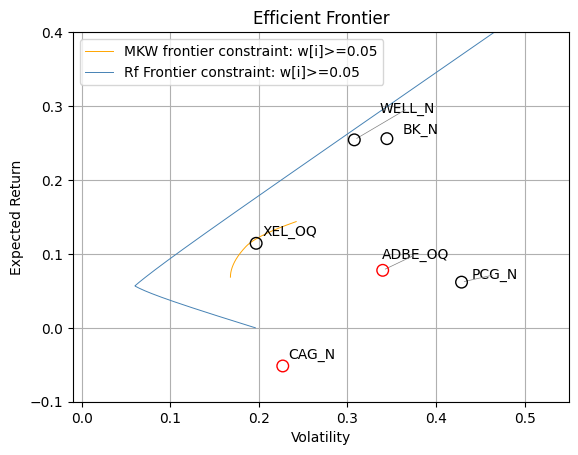

In [ ]:
y3          = np.array(volatility_c_2)
y4          = np.array(volatility_c_2_rf)

plt.plot(y3, mu_p_plot2[0:len(y3)], label = 'MKW frontier constraint: w[i]>=0.05',color ='orange', lw = 0.7)
plt.plot(y4, mu_p_plot1[0:len(y4)], label = 'Rf Frontier constraint: w[i]>=0.05',color = 'steelblue', lw = 0.7)


plt.scatter(
    np.sqrt(np.diag(sigma_scc)), mu_exp,
    facecolors='none',
    edgecolors= ['red','black', 'red'] + ['black']*3,
    s=70,
    linewidths=1,
    zorder=5,
)

if False:
    plt.scatter(
        MKW_rf['vol_tan'],
        MKW_rf['mu_tan'],
        facecolors='none',
        edgecolors='red',
        s=70,
        linewidths=1,
        zorder=5
    )

    plt.scatter(
        MKW['min_vol'],
        MKW['min_mu'],
        facecolors='none',
        edgecolors='blue',
        s=70,
        linewidths=1,
        zorder=5
    )


texts = []

for xi, yi, name in zip(np.sqrt(np.diag(sigma_scc)), mu_exp, asset_names):

    txt = plt.text(xi, yi, name, fontsize=10)
    texts.append(txt)

if False:
    txt = plt.text(MKW_rf['vol_tan'],
                MKW_rf['mu_tan'], 'Tangent', fontsize=10)
    texts.append(txt)

    txt = plt.text(MKW['min_vol'],
                MKW['min_mu'], 'MVP', fontsize=10)
    texts.append(txt)

adjust_text(
    texts,
    x=np.sqrt(np.diag(sigma_scc)),# + [MKW['min_vol']] + [MKW_rf['vol_tan']]
    y=mu_exp ,#+ [MKW['min_mu']]+ [MKW_rf['mu_tan']]
    expand_points=(1.5, 1.5),
    expand_text=(1.2, 1.2),
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5)
)


plt.ylim((-0.1,0.4))
plt.xlim((-0.01,0.55))
plt.xlabel('Volatility')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

### Portafoglio a rendimento dato

In [ ]:
mu_p = 0.005 * 12
mu_p

0.06

In [ ]:
#portafoglio con rendimenti mensili del 0.5% (senza risk free)

p = sigma_frontier(mu_p, mu_exp, sigma_scc)

print(f'weights :{p['weights']}')
print(f'volatility :{p['volatility']}')

weights :[0.07028295 0.48754686 0.36740044 0.02002117 0.00656818 0.0481804 ]
volatility :0.1669167659539687


In [ ]:
#portafoglio con rendimenti mensili (senza rf) del 0.5% constraint 1

res = min_var_portfolio(mu_exp, sigma_scc, mu_p, bounds = None, eq_constraints = True, w0=w0)

w_c = res.x
v_c = np.sqrt(w_c.T @ sigma_scc @ w_c)
print(f'weights constraint w[1] + w[3] = 0.40 :{w_c}')
print(f'volatility constraint w[1] + w[3] = 0.40 :{v_c}')

weights constraint w[1] + w[3] = 0.40 :[0.04590509 0.53136669 0.35409491 0.01589562 0.0181701  0.03456759]
volatility constraint w[1] + w[3] = 0.40 :0.1673486298897924


In [ ]:
#portafoglio con rendimenti mensili (senza rf) del 0.5% constraint 2

res = min_var_portfolio(mu_exp, sigma_scc, mu_p, bounds = [(0.05, None)] * 6, eq_constraints = False, w0 = w0)

w_c = res.x
v_c = np.sqrt(w_c.T @ sigma_scc @ w_c)

print(f'weights constraint w[i] > 0.05 :{w_c}')
print(f'volatility constraint  w[i] > 0.05 :{v_c}')

weights constraint w[i] > 0.05 :[0.05119467 0.41384045 0.38496489 0.05       0.05       0.05      ]
volatility constraint  w[i] > 0.05 :0.16838975213023946


In [ ]:
#portafoglio con rendimenti mensili del 0.5%

p = sigma_frontier(mu_p, mu_exp, sigma_scc, rf)

print(f'weights :{p['weights']}'*100)
print(f'volatility :{p['volatility']}')

weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.01305268  0.04089109 -0.07788557  0.04192801 -0.00925291  0.05191023]weights :[-0.013

In [ ]:
#portafoglio con rendimenti mensili del 0.5% constraint 1

res = min_var_portfolio_rf(mu_exp, sigma_scc, mu_p, rf, bounds = None, eq_constraints = True, w0 = w0)

w_c = res.x
v_c = np.sqrt(w_c.T @ sigma_scc @ w_c)

print(f'weights constraint w[1] + w[3] = 0.40 :{w_c}')
print(f'volatility constraint  w[1] + w[3] = 0.40 :{v_c}')

weights constraint w[1] + w[3] = 0.40 :[ 0.18164142 -0.02565184  0.21835858  0.05776507 -0.07554704  0.13674446]
volatility constraint  w[1] + w[3] = 0.40 :0.11275458029176744


In [ ]:
#portafoglio con rendimenti mensili del 0.5% constraint 2

res = min_var_portfolio_rf(mu_exp, sigma_scc, mu_p, rf, bounds = True * 6, eq_constraints = False, w0 = w0)

w_c = res.x
v_c = np.sqrt(w_c.T @ sigma_scc @ w_c)

print(f'weights constraint w[i] > 0.05 :{w_c}')
print(f'volatility constraint  w[i] > 0.05 :{v_c}')

weights constraint w[i] > 0.05 :[0.05       0.05       0.05       0.05       0.05       0.06509222]
volatility constraint  w[i] > 0.05 :0.06319819392613957


## Eercizio 5

### Data

In [ ]:
full_ret        = sp_ret.join(group_ret, how = "left")
full_ret.head()

,SP_RET,ADBE_OQ,XEL_OQ,CAG_N,BK_N,PCG_N,WELL_N
Date,,,,,,,
2003-12-31T00:00:00Z,NaN,-0.012563,-0.001176,0.006484,-0.004808,-0.005729,0.001112
2004-01-02T00:00:00Z,-0.003094,-0.004580,-0.000589,-0.014778,-0.009360,-0.019445,-0.002778
2004-01-05T00:00:00Z,0.012395,0.020706,0.000000,0.017308,0.041756,0.004407,0.004735
2004-01-06T00:00:00Z,0.001292,-0.001503,0.000000,-0.005293,0.015506,-0.008044,0.001663
2004-01-07T00:00:00Z,0.002367,-0.010628,0.008839,0.001140,-0.034572,-0.001106,0.000554


### CAPM

In [ ]:
rf = 0.02 / 252

In [ ]:
# svolgo le regressioni richieste, una per ogni asset del ptf secono il modello CAPM

capm_results = {}

for ticker in group_tickers:

    ri = full_ret[ticker] - rf
    rm = full_ret['SP_RET'] - rf

    X = sm.add_constant(rm)

    model = sm.OLS(ri, X, missing='drop').fit()

    capm_results[ticker] = {
        "alpha": model.params['const'],
        "alpha_pvalue": model.pvalues['const'],
        "beta": model.params['SP_RET'],
        "beta_pvalue": model.pvalues['SP_RET'],
        "R_squared": model.rsquared
    }


In [ ]:
pd.DataFrame(capm_results).T

,alpha,alpha_pvalue,beta,beta_pvalue,R_squared
ADBE_OQ,0.000315,0.137040,1.188259,0.000000e+00,0.428339
XEL_OQ,0.000261,0.060231,0.549395,0.000000e+00,0.271249
CAG_N,0.000056,0.749694,0.435073,2.788210e-171,0.127167
BK_N,0.000105,0.596903,1.321176,0.000000e+00,0.514393
PCG_N,0.000111,0.740905,0.699667,5.151274e-124,0.093378
WELL_N,0.000415,0.049362,0.926118,0.000000e+00,0.314588


## Esercizio 6-7

In [ ]:
# Sovrascivo rendimenti e volatilità su base mensile in coerenza con la view richieste

mu       = group_ret.mean() * 21
sigma    = group_ret.cov() * 21
sigma_np = sigma.to_numpy()
vol      = np.sqrt(np.diag(sigma))
sigma_scc,_,_ = Sigma_cc(group_ret,k = 0.35)

sigma_scc = sigma_scc/12

rf = 0.03

In [ ]:
# Calcolo portafoglio di mercato
w_mkt    = mkt_cap.values / tot_cap

# Calcolo rendimenti impiciti del mercato (prior)
PI        = sigma_scc @ w_mkt

# Calcolo formula B&L senza view sui rendimenti
PI_new    = sigma_scc @ (np.linalg.inv(sigma_scc) @ PI)
PI*100

,0
ADBE_OQ,0.509815
XEL_OQ,0.202115
CAG_N,0.160399
BK_N,0.457856
PCG_N,0.376517
WELL_N,0.435183


In [ ]:
# calcolo view su Adobe
Q = np.array([0.0416])
P = np.array([[1, 0, 0, 0, 0, 0]])
Certainty1 = 0.45


Omega1 = (P @ sigma_scc @ P.T) * (1 - Certainty1)/Certainty1

sigma_inv = np.linalg.inv(sigma_scc)
omega_inv = np.linalg.inv(Omega1)

precision_posterior = sigma_inv + P.T @ omega_inv @ P


PI_new = np.linalg.inv(precision_posterior) @ (sigma_inv @ PI + P.T @ omega_inv @ Q)

Sigma_pred = np.linalg.inv(precision_posterior) + sigma_scc
w_new = (np.linalg.inv(Sigma_pred) @ PI_new)/np.sum(np.linalg.inv(Sigma_pred)@ PI_new)


print(f"\n View: Adobe (ADBE_OQ) con rendimento atteso = {Q[0]:.2%} mensile")
print(f"Livello di confidenza: {Certainty1:.1%}")

print(f"\nPI_new con Black-Litterman:")
for i, ticker in enumerate(group_tickers):
    print(f"{ticker}: {PI_new[i]:.4f} (delta: {PI_new[i]-PI[i]:+.4f})")

print(f'Porafoglio BL{w_new}')


 View: Adobe (ADBE_OQ) con rendimento atteso = 4.16% mensile
Livello di confidenza: 45.0%

PI_new con Black-Litterman:
ADBE_OQ: 0.0215 (delta: +0.0164)
XEL_OQ: 0.0050 (delta: +0.0030)
CAG_N: 0.0042 (delta: +0.0026)
BK_N: 0.0108 (delta: +0.0063)
PCG_N: 0.0085 (delta: +0.0048)
WELL_N: 0.0091 (delta: +0.0048)
Porafoglio BL[0.80106172 0.0298009  0.00567938 0.05583016 0.02198833 0.0856395 ]


/tmp/ipython-input-582753049.py:26: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{ticker}: {PI_new[i]:.4f} (delta: {PI_new[i]-PI[i]:+.4f})")


In [ ]:
# Calcolo view su Conagra

Q = np.array([0.0046])
P = np.array([[0, 0, 1, 0, 0, 0]])
Certainty2 = 0.60

Omega2 = np.diag([Certainty2 * P[0] @ sigma_scc @ P[0].T])


sigma_inv = np.linalg.inv(sigma_scc)
omega_inv = np.linalg.inv(Omega2)


precision_posterior = sigma_inv + P.T @ omega_inv @ P


PI_new2 = np.linalg.inv(precision_posterior) @ (sigma_inv @ PI + P.T @ omega_inv @ Q)

Sigma_pred_2 = np.linalg.inv(precision_posterior) + sigma_scc
w_new_2 = (np.linalg.inv(Sigma_pred_2) @ PI_new2)/np.sum(np.linalg.inv(Sigma_pred_2)@ PI_new2)

print(f"\n View: Conagra (CAG_N) con rendimento atteso = {Q[0]:.2%} mensile")
print(f"Livello di confidenza: {Certainty2:.1%}")

print(f"\nPI_new con Black-Litterman:")
for i, ticker in enumerate(group_tickers):
    print(f"{ticker}: {PI_new2[i]:.4f} (delta: {PI_new2[i]-PI[i]:+.4f})")

print(f'Portafoglio BL:{w_new_2}')


 View: Conagra (CAG_N) con rendimento atteso = 0.46% mensile
Livello di confidenza: 60.0%

PI_new con Black-Litterman:
ADBE_OQ: 0.0058 (delta: +0.0007)
XEL_OQ: 0.0025 (delta: +0.0005)
CAG_N: 0.0035 (delta: +0.0019)
BK_N: 0.0053 (delta: +0.0008)
PCG_N: 0.0045 (delta: +0.0008)
WELL_N: 0.0050 (delta: +0.0007)
Portafoglio BL:[0.18408588 0.05543809 0.45639802 0.10385987 0.0409045  0.15931366]


/tmp/ipython-input-4191606767.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{ticker}: {PI_new2[i]:.4f} (delta: {PI_new2[i]-PI[i]:+.4f})")


In [ ]:
tot_w = pd.concat([
    PI.reset_index(drop=True),
    pd.Series(PI_new, name='PI_ADBE'),
    pd.Series(PI_new2, name='PI_CAG_N')
], axis=1)
tot_w.columns = ['PI', 'PI_ADBE', 'PI_CAG_N']
tot_w*100


,PI,PI_ADBE,PI_CAG_N
0,0.509815,2.152399,0.576869
1,0.202115,0.497362,0.254613
2,0.160399,0.422794,0.347650
3,0.457856,1.084838,0.534974
4,0.376517,0.851523,0.453493
5,0.435183,0.914142,0.500412
